In [1]:
cd ../

c:\Users\eduar\Documents\usp\AMST\ml_timeseries_usp


In [18]:
import os
from src.data.make_dataset import DatasetCreator
from src.data.make_hierarchical_dataset import DatasetHierarchicalAggregator
from src.data.refine_dataset import HierarchicalTimeSeriesOutlierRemover
from src.data.split import HierarchicalTrainTestSplit
from src.features.build_features import FeaturesBuilder
from src.config import load_config
from src.models.tuning import ModelTuning
from src.models.train_model import CreateCanditateModel
from src.evaluation.backtest_evaluation import ModelEvaluate,CompareRecMethods
from src.data.back_to_origin import DatasetReconciliator
import warnings
import shap
warnings.filterwarnings("ignore")
config = load_config()

if config['cache']:

    print('loading data...')
    ## == LOAD AGGREGATED DATASETS AND OBJECTS 
    Hagg = DatasetHierarchicalAggregator(config)
    
    Y_df = Hagg.load_processed(filename='dataset.parquet')
    S_df = Hagg.load_processed(filename='structure.parquet')
    tags = Hagg.load_tags(filename='tags.joblib')
    Y_exogen_cat_df = Hagg.load_processed(filename='exog_cat_vars.parquet')
    Y_exogen_num_df = Hagg.load_processed(filename='exog_num_vars.parquet')
    future_df = Hagg.load_processed(filename='future.parquet')

    pass

else:
    ## == CREATE DATASET
    df = DatasetCreator(config).run()

    ## == HIERARCHICAL AGGREGATION
    Y_df, S_df, tags, Y_exogen_cat_df, Y_exogen_num_df, future_df = DatasetHierarchicalAggregator(config,df=df).run()

## == HIERARCHICAL TRAIN TEST SPLIT
split_dates = config['split_dates']
train , test = HierarchicalTrainTestSplit(Y_df, S_df, tags, Y_exogen_cat_df, Y_exogen_num_df,split_dates,config).run()

2025-12-09 18:38:03,771 - INFO - Config carregado de c:\Users\eduar\Documents\usp\AMST\ml_timeseries_usp\config.yaml


loading data...
DEBUG: Iniciando carregamento de data/processed/global\dataset.parquet
DEBUG: Dataset Carregado.
DEBUG: Iniciando carregamento de data/processed/global\structure.parquet
DEBUG: Dataset Carregado.
DEBUG: Carregando tags de tags.joblib
DEBUG: Iniciando carregamento de data/processed/global\exog_cat_vars.parquet
DEBUG: Dataset Carregado.
DEBUG: Iniciando carregamento de data/processed/global\exog_num_vars.parquet
DEBUG: Dataset Carregado.
DEBUG: Iniciando carregamento de data/processed/global\future.parquet
DEBUG: Dataset Carregado.
Train: 2022-01-01 → 2025-01-01 (37 meses)
Test (backtest): 2025-02-01 → 2025-07-01 (6 meses)


In [ ]:
models = config['models']
cv_config = config['modeling']['cv_config']
methods = config['reconciliation']['methods']
min_trace_methods = config['reconciliation']['min_trace_methods']
mid_level = config['reconciliation']['middle_level']
train_metrics_path = config['paths']['metrics']['train_path']
evaluation_metrics_path = config['paths']['metrics']['evaluation_path']
time_col = config['time_col']
id_col = config['id_col']
target_col = config['target_col']

candidate_info = {}
candidate_performances = {}

model = 'XGBoost'

train_to_model = train.copy()
test_to_model = test.copy()


type_model = models[model]['type']
training_metric = config['modeling']['training_metric']
validation_metric = config['modeling']['validation_metric']
train_compare_metrics = config['modeling']['train_compare_metrics']
test_compare_metrics = config['modeling']['test_compare_metrics']
model_name = models[model]['name']

In [36]:
#Get Tuning info
fixed_params = models[model]['fixed_params']
param_space = config['parameter_space'][model]
mlforecast_params = config['modeling']['mlforecast']
static_features = mlforecast_params['fit_params']['static_features']

In [37]:
from mlforecast import MLForecast
from utilsforecast.losses import smape,mape,mase
import shap
import pandas as pd
import numpy as np
import optuna
from mlforecast.optimization import mlforecast_objective
from xgboost import XGBRegressor
from mlforecast.target_transforms import LocalBoxCox,Differences,LocalStandardScaler,LocalMinMaxScaler
from mlforecast.lag_transforms import RollingMean, ExpandingMean
def config_fn(trial):
    candidate_lags = [
        [1],
        [13],
        [1, 13],
        range(1, 33),
    ]
    lag_idx = trial.suggest_categorical('lag_idx', range(len(candidate_lags)))
    candidate_lag_tfms = [
        {
            1: [RollingMean(window_size=13)]
        },
        {
            1: [RollingMean(window_size=13)],
            13: [RollingMean(window_size=13)],
        },
        {
            13: [RollingMean(window_size=13)],
        },
        {
            4: [ExpandingMean(), RollingMean(window_size=4)],
            8: [ExpandingMean(), RollingMean(window_size=4)],
        }
    ]
    lag_tfms_idx = trial.suggest_categorical('lag_tfms_idx', range(len(candidate_lag_tfms)))
    candidate_targ_tfms = [
        [Differences([1])],
        [LocalBoxCox()],
        [LocalStandardScaler()],        
        [LocalBoxCox(), Differences([1])],
        [LocalBoxCox(), LocalStandardScaler()],
        [LocalBoxCox(), Differences([1]), LocalStandardScaler()],
    ]
    targ_tfms_idx = trial.suggest_categorical('targ_tfms_idx', range(len(candidate_targ_tfms)))
    return {
        'model_params': {
            'eta': trial.suggest_float('eta',0.01,0.1), 
            'objective': 'reg:squarederror',
            'n_jobs': 2,
            'verbosity': 0,
            'tree_method': 'hist', # Approximation for 'force_col_wise': True
            'n_estimators': trial.suggest_int('n_estimators', 10, 1000, log=True),            
            'max_depth': trial.suggest_int('max_depth', 5, 10, log=True), # Approximation for 'num_leaves'; adjust as 2**max_depth ≈ num_leaves
            'reg_alpha': trial.suggest_float('lambda_l1', 0.01, 10, log=True),
            'reg_lambda': trial.suggest_float('lambda_l2', 0.01, 10, log=True),
            'subsample': trial.suggest_float('subsample', 0.75, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.75, 1.0),
            'enable_categorical': True,
        },
        'mlf_init_params': {
            'lags': candidate_lags[lag_idx],
            'lag_transforms': candidate_lag_tfms[lag_tfms_idx],
            'target_transforms': candidate_targ_tfms[targ_tfms_idx],
            'date_features': ['month', 'quarter']
        },
        'mlf_fit_params': {
            'static_features': static_features
        }
    }

def loss(df, train_df):
    return mase(df, models=['model'],train_df=train,seasonality=config['seasonality'])['model'].mean()

In [38]:
optuna.logging.set_verbosity(optuna.logging.INFO)
objective = mlforecast_objective(
    df=train,
    config_fn=config_fn,
    loss=loss,    
    model=XGBRegressor(),
    freq='MS',
    n_windows=1,
    h=1,
)
study = optuna.create_study(
    direction='minimize', sampler=optuna.samplers.TPESampler(seed=1)
)

[I 2025-12-09 19:44:25,887] A new study created in memory with name: no-name-1aab69ff-6797-4568-b75f-8df7be18fe3b


In [ ]:
study.optimize(objective, n_trials=80)
best_value = study.best_value
best_trial_cfg = study.best_trial.user_attrs['config']
best_model_params = best_trial_cfg['model_params']
best_mlforecast_params = best_trial_cfg['mlf_init_params']
mlf_fit_params = best_trial_cfg['mlf_fit_params']

[I 2025-12-09 19:44:30,306] Trial 0 finished with value: 1.400150785845713e+21 and parameters: {'lag_idx': 1, 'lag_tfms_idx': 3, 'targ_tfms_idx': 5, 'eta': 0.012464883387813356, 'n_estimators': 216, 'max_depth': 6, 'lambda_l1': 0.47431786810463206, 'lambda_l2': 0.02637307779092461, 'subsample': 0.7995253722712197, 'colsample_bytree': 0.9501861421688842}. Best is trial 0 with value: 1.400150785845713e+21.
[I 2025-12-09 19:44:41,209] Trial 1 finished with value: 8761.60332910631 and parameters: {'lag_idx': 0, 'lag_tfms_idx': 0, 'targ_tfms_idx': 3, 'eta': 0.03839640679054567, 'n_estimators': 232, 'max_depth': 9, 'lambda_l1': 0.011346576147006612, 'lambda_l2': 1.7800530470464975, 'subsample': 0.9972152722266237, 'colsample_bytree': 0.9370414135949598}. Best is trial 1 with value: 8761.60332910631.
[I 2025-12-09 19:44:41,917] Trial 2 finished with value: 2.192336445456503 and parameters: {'lag_idx': 1, 'lag_tfms_idx': 0, 'targ_tfms_idx': 1, 'eta': 0.061670584494281186, 'n_estimators': 19, '

In [25]:
final_model = MLForecast(
    models=[XGBRegressor(**best_model_params)],
    freq='MS',
    **best_mlforecast_params,
)

In [26]:
X = mlf_xgb.preprocess(train,static_features=static_features)

In [ ]:
df_preds = 

In [27]:
print(smape(df_preds,models='XGBRegressor')[0].mean(),
      mape(df_preds,models='XGBRegressor')[0].mean())

NameError: name 'df_preds' is not defined

<Axes: >

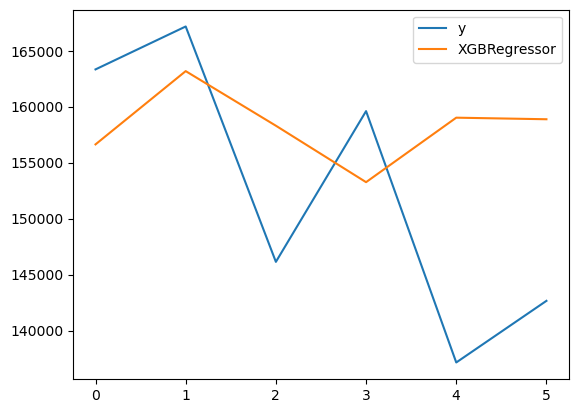

In [13]:
df_preds[df_preds['unique_id']=='total'][['y','XGBRegressor']].plot()

In [67]:
final_model.models_['XGBRegressor']

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9319853415264213, device=None,
             early_stopping_rounds=None, enable_categorical=True,
             eta=0.08040493529216956, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=9,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=612,
             n_jobs=2, ...)

In [15]:
xgb_model = mlf_xgb.models_['XGBRegressor']
explainer = shap.TreeExplainer(xgb_model,X)
shap_values = explainer(X)

NameError: name 'X' is not defined

In [85]:
import matplotlib.pyplot as plt

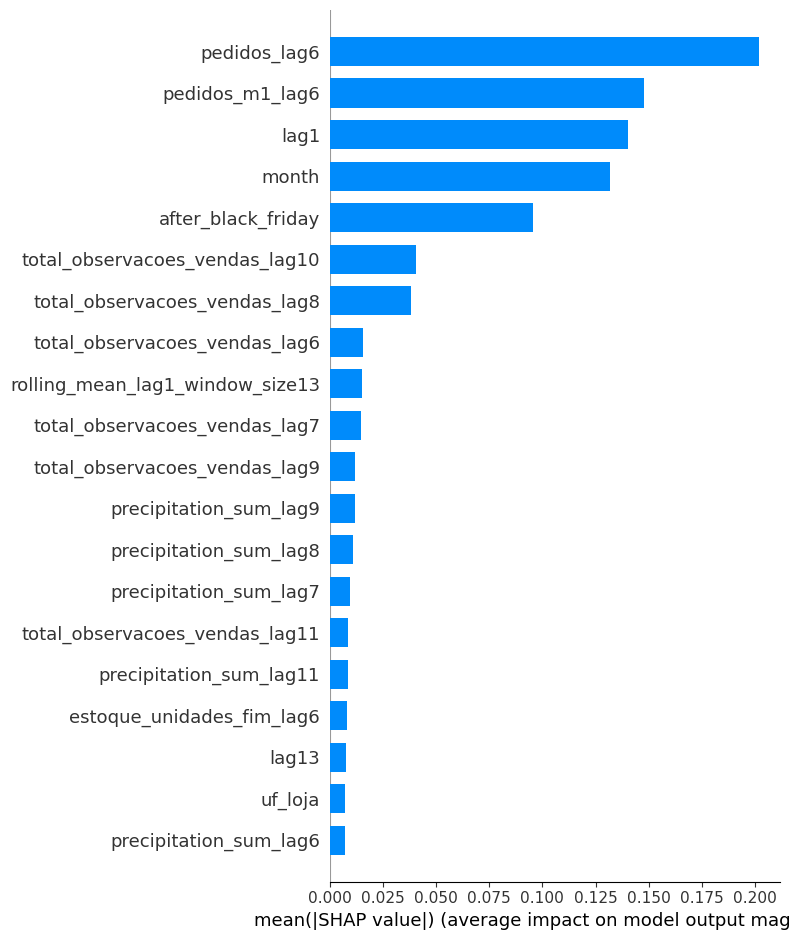

In [86]:
shap.summary_plot(shap_values, X, plot_type="bar")  # Versão em barras para importância global
plt.show()  # Ou plt.savefig('importancia_global.png') para salvar como imagem

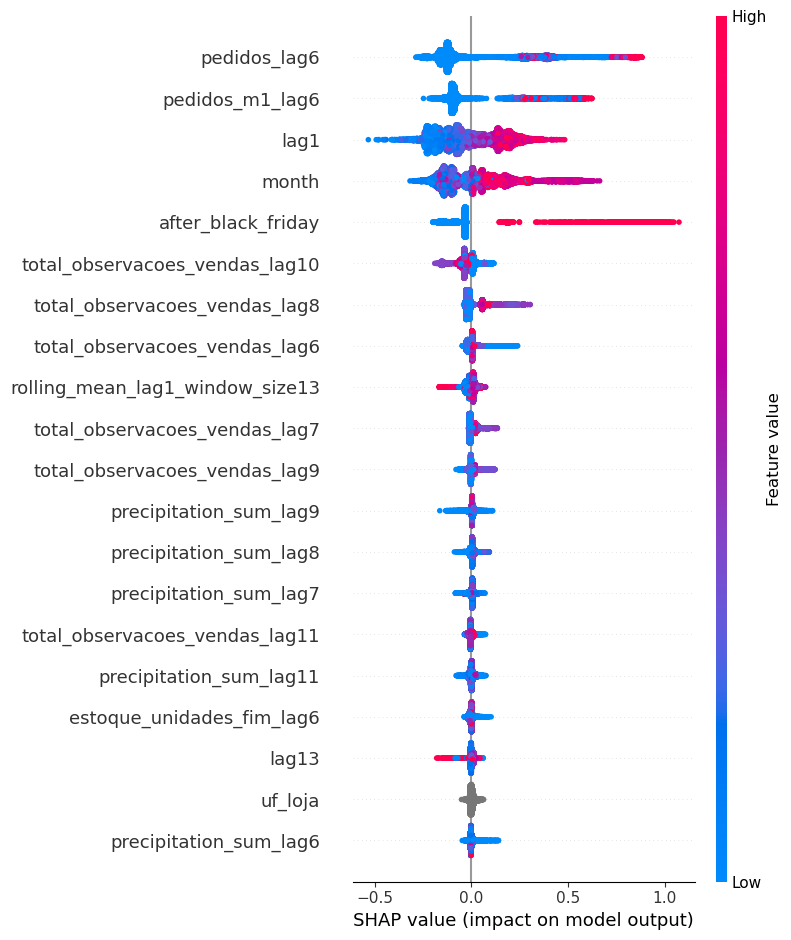

In [87]:
shap.summary_plot(shap_values, X)  # Beeswarm por default
plt.show()

In [97]:
# Assuming shap.initjs() is already called for Jupyter
shap.force_plot(explainer.expected_value, shap_values[0].values, X.iloc[0])

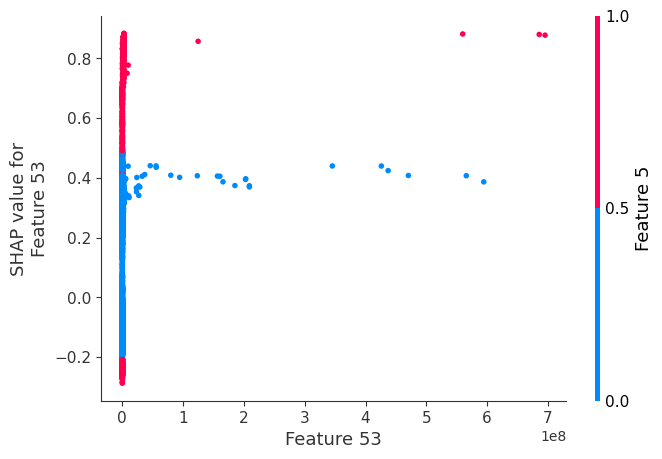

In [101]:
feature_names = list(X.columns)
uf_loja_index = feature_names.index('pedidos_lag6')

# Use shap_values.values (the NumPy array)
shap.dependence_plot(uf_loja_index, shap_values.values, X.values)
plt.show()

In [30]:
#create model with best tuning parameters
CM = CreateCanditateModel(
                    df=train_to_model,
                    config=config,
                    cv_config=cv_config,
                    type_model=type_model,
                    model_name=model_name,
                    metric=best_value,
                    cv_metric = training_metric,
                    compare_metrics=train_compare_metrics,
                    model_params = best_model_params,
                    mlf_params = best_mlforecast_params,
                    mlf_fit_params = mlf_fit_params
                    )

In [31]:
results_metrics = None
fitted_values = None

if CM.type_model == 'statsforecast':
    model_artifact = CM.create_stats_model()
    results_metrics = CM.cross_validation(model_artifact)
    pass
else:
    #mlforecast
    static_features = CM.mlf_fit_params['static_features']
    model_artifact = CM.create_mlf_model()
    results_metrics = CM.cross_validation(model_artifact,static_features=static_features)
    pass

#CM.save_evaluation_metrics(results_metrics)
#fitted_model = CM.fit_model(model_artifact)
#CM.save_model(fitted_model)
#CM.save_fitted_values(fitted_model)
#CM.save_metric_params(results_metrics=results_metrics,filename='info.json')
#fitted_values = CM.load_fitted_values()
#
##model = CM.load_model()
#metric = CM.load_metric(filename='info.json')
#
#return fitted_model, fitted_values, metric, results_metrics
#


Calculando erro por série usando métrica principal: mase ...

=== Séries selecionadas para plot de CV ===
Hierarquia 'root' → 1 séries → todas em best_cases
Hierarquia 'total' → 2 séries → todas em best_cases
Hierarquia 'total/blusa' → 3 séries → todas em best_cases
Hierarquia 'total/blusa/cd1' → 84 séries → 5 melhores + 5 piores
Hierarquia 'total/blusa/cd2' → 233 séries → 5 melhores + 5 piores
Hierarquia 'total/blusa/cd3' → 9 séries → todas em best_cases
Hierarquia 'total/calca' → 3 séries → todas em best_cases
Hierarquia 'total/calca/cd1' → 81 séries → 5 melhores + 5 piores
Hierarquia 'total/calca/cd2' → 172 séries → 5 melhores + 5 piores
Hierarquia 'total/calca/cd3' → 8 séries → todas em best_cases

Total de plots gerados:
→ best_cases:  46 séries
→ worst_cases: 20 séries
Organização: cross_validation → [hierarquia] → best_cases / worst_cases (só quando >10)



In [32]:
static_features

['unique_id']

In [39]:
#create model with best tuning parameters
candidate, fitted_values, metric,results_metrics = CreateCanditateModel(
                    df=train_to_model,
                    config=config,
                    cv_config=cv_config,
                    type_model=type_model,
                    model_name=model_name,
                    metric=best_value,
                    cv_metric = training_metric,
                    compare_metrics=train_compare_metrics,
                    model_params = best_model_params,
                    mlf_params = best_mlforecast_params,
                    mlf_fit_params = mlf_fit_params
                    ).run()
        
candidate_info.update({metric:candidate})
candidate_performances.update({model:results_metrics})

#eavluate model
prediction,validation_metric,results_metrics = ModelEvaluate(
                        candidate_model=final_model,
                        model_name=model_name,
                        fitted_values=fitted_values,
                        type_model=type_model,
                        train=train_to_model,
                        test=test_to_model,
                        validation_metric=validation_metric,
                        compare_metrics=test_compare_metrics,
                        config=config
                        ).run()

#Hierarchical Reconcilier
df_post_processed,recmethods = DatasetReconciliator(
                Y_df = Y_df,
                S_df = S_df,
                tags = tags,
                model_name = model_name,
                methods = methods,
                mid_level = mid_level,
                min_trace_methods = min_trace_methods,
                fitted_values = fitted_values,
                prediction = prediction
            ).run()

CompareRecMethods(
                        model_name=model_name,
                        df_post_processed=df_post_processed,      # seu df com as colunas reconciliadas (com "/")
                        fitted_values=fitted_values,       # só unique_id, ds, y do treino
                        test=test_to_model[[id_col,time_col,target_col]],                  # unique_id, ds, y do período de teste
                        config=config
                    ).run()

                            
for method in recmethods:
    
    df_rec_method = df_post_processed[[id_col,time_col,method]]

    # Evaluate with each hierarchical reconcilier
    prediction,validation_metric,results_metrics = ModelEvaluate(
                                                        candidate_model=None,
                                                        model_name=method,
                                                        fitted_values=fitted_values,
                                                        type_model=type_model,
                                                        train=train_to_model,
                                                        test=test_to_model,
                                                        validation_metric=validation_metric,
                                                        compare_metrics=test_compare_metrics,
                                                        config=config,
                                                        prediction=df_rec_method
                                                        ).run()

    


Calculando erro por série usando métrica principal: mase ...

=== Séries selecionadas para plot de CV ===
Hierarquia 'root' → 1 séries → todas em best_cases
Hierarquia 'total' → 2 séries → todas em best_cases
Hierarquia 'total/blusa' → 3 séries → todas em best_cases
Hierarquia 'total/blusa/cd1' → 84 séries → 5 melhores + 5 piores
Hierarquia 'total/blusa/cd2' → 233 séries → 5 melhores + 5 piores
Hierarquia 'total/blusa/cd3' → 9 séries → todas em best_cases
Hierarquia 'total/calca' → 3 séries → todas em best_cases
Hierarquia 'total/calca/cd1' → 81 séries → 5 melhores + 5 piores
Hierarquia 'total/calca/cd2' → 172 séries → 5 melhores + 5 piores
Hierarquia 'total/calca/cd3' → 8 séries → todas em best_cases

Total de plots gerados:
→ best_cases:  46 séries
→ worst_cases: 20 séries
Organização: cross_validation → [hierarquia] → best_cases / worst_cases (só quando >10)


Calculando erro por série no backtest usando métrica: smape ...

=== Plotando séries selecionadas no backtest (máx 10 por h